# Customer Support Ticket Analytics Project

## Priority Classification using NLP and Deep Learning

### Objective

Build a multi-class classification model to predict ticket priority:

- Urgent
- High
- Medium
- Low

### Models

Traditional ML:
- Logistic Regression
- Random Forest

Deep Learning:
- LSTM Neural Network

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Data/final_customer_support.csv")

print(df.shape)

df.head()

(200000, 36)


,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,language,preferred_contact_time,issue_complexity_score,customer_segment,issue_length,resolution_length,ticket_duration_days,created_year,created_month,created_dayofweek
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,French,Afternoon,4,Small Business,79,60,3,2023,5,2
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,English,Afternoon,2,Small Business,63,70,13,2024,1,5
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,French,Morning,4,Corporate,56,70,5,2022,11,2
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,Spanish,Afternoon,7,Corporate,74,70,14,2024,3,3
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,Spanish,Evening,3,Corporate,55,78,8,2024,8,4


In [3]:
df["combined_text"] = (
    df["issue_description"].astype(str)
    + " "
    + df["resolution_notes"].astype(str)
)

df["combined_text"].head()

0    The payment was deducted from my bank account ...
1    I found a bug in the latest update affecting r...
2    The application crashes whenever I try to uplo...
3    My subscription was cancelled without my reque...
4    The system is not syncing data across devices ...
Name: combined_text, dtype: str

In [4]:
le = LabelEncoder()

df["priority_encoded"] = le.fit_transform(
    df["priority"]
)

print(le.classes_)

['High' 'Low' 'Medium' 'Urgent']


In [5]:
X = df["combined_text"]

y = df["priority_encoded"]

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [7]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [8]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (140000,)
Validation: (30000,)
Test: (30000,)


In [9]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)

X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(140000, 133)


In [10]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_tfidf,
    y_train
)

lr_pred = lr.predict(X_test_tfidf)

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

print(
    "Logistic Regression Accuracy:",
    round(lr_accuracy*100,2),
    "%"
)

Logistic Regression Accuracy: 25.3 %


In [11]:
print(
    classification_report(
        y_test,
        lr_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

        High       0.26      0.41      0.31      7536
         Low       0.25      0.20      0.22      7464
      Medium       0.26      0.12      0.17      7478
      Urgent       0.25      0.28      0.26      7522

    accuracy                           0.25     30000
   macro avg       0.25      0.25      0.24     30000
weighted avg       0.25      0.25      0.24     30000



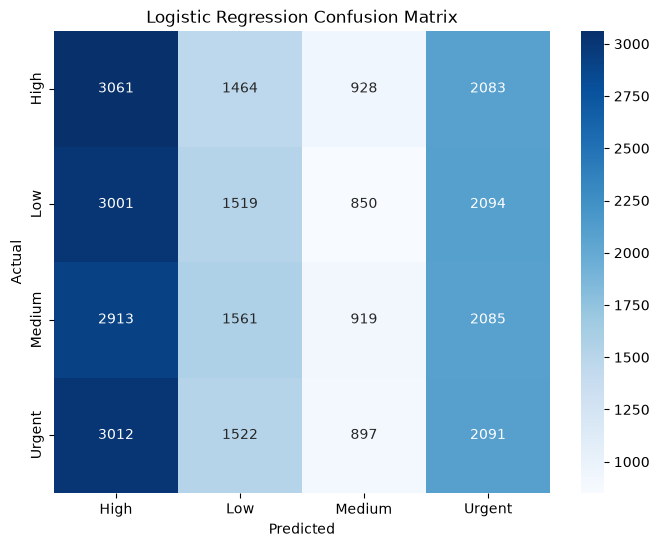

In [12]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_tfidf,
    y_train
)

rf_pred = rf.predict(
    X_test_tfidf
)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy*100,2),
    "%"
)

Random Forest Accuracy: 24.76 %


In [14]:
results_df = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy":[
        lr_accuracy,
        rf_accuracy
    ]
})

results_df

,Model,Accuracy
0,Logistic Regression,0.2530
1,Random Forest,0.2476


In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical

In [16]:
max_words = 5000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

In [17]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_val_seq = tokenizer.texts_to_sequences(X_val)

X_test_seq = tokenizer.texts_to_sequences(X_test)

In [18]:
print(X_train.iloc[0])

print("\nSequence:\n")

print(X_train_seq[0])

I would like to request a refund for the recent charge. Data synchronization restored after backend service restart.

Sequence:

[6, 36, 37, 4, 23, 7, 15, 13, 2, 38, 16, 25, 100, 101, 21, 102, 103, 104]


In [19]:
max_len = 100

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_len,
    padding="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding="post"
)

In [20]:
y_train_cat = to_categorical(
    y_train,
    num_classes=4
)

y_val_cat = to_categorical(
    y_val,
    num_classes=4
)

y_test_cat = to_categorical(
    y_test,
    num_classes=4
)

In [21]:
print(X_train_pad.shape)

print(y_train_cat.shape)

(140000, 100)
(140000, 4)


In [22]:
model = Sequential()

model.add(
    Embedding(
        input_dim=5000,
        output_dim=128,
        input_length=100
    )
)

model.add(
    LSTM(
        64,
        return_sequences=False
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        32,
        activation="relu"
    )
)

model.add(
    Dense(
        4,
        activation="softmax"
    )
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
history = model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(
        X_val_pad,
        y_val_cat
    ),
    epochs=3,
    batch_size=256
)

Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 134s 237ms/step - accuracy: 0.2504 - loss: 1.3866 - val_accuracy: 0.2512 - val_loss: 1.3863
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 120s 219ms/step - accuracy: 0.2514 - loss: 1.3863 - val_accuracy: 0.2507 - val_loss: 1.3863
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 123s 225ms/step - accuracy: 0.2488 - loss: 1.3864 - val_accuracy: 0.2512 - val_loss: 1.3863


In [25]:
loss, accuracy = model.evaluate(
    X_test_pad,
    y_test_cat
)

print(
    f"LSTM Accuracy: {accuracy*100:.2f}%"
)

938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.2512 - loss: 1.3863
LSTM Accuracy: 25.12%


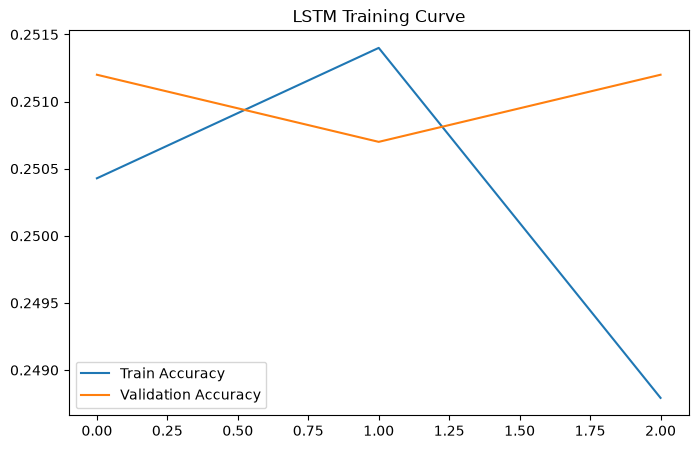

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.legend()

plt.title("LSTM Training Curve")

plt.show()

In [27]:
comparison_df = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "LSTM"
    ],
    "Accuracy":[
        0.2530,
        0.2476,
        accuracy
    ]
})

comparison_df

,Model,Accuracy
0,Logistic Regression,0.2530
1,Random Forest,0.2476
2,LSTM,0.2512


In [28]:
import os

os.makedirs("models", exist_ok=True)

model.save("models/priority_lstm.keras")

In [29]:
import pickle

with open(
    "models/priority_tokenizer.pkl",
    "wb"
) as f:
    pickle.dump(tokenizer, f)

with open(
    "models/priority_encoder.pkl",
    "wb"
) as f:
    pickle.dump(le, f)

print("Priority tokenizer and encoder saved")

Priority tokenizer and encoder saved
